# Anticipating Data Cleaning Issues when Importing Tabular Data into pandas
## Solution Notebook (Extended Cookbook)

**Source:** Python Data Cleaning Cookbook – Chapter 1  
Complete working solutions, alternate implementations, extra practice answers, and a parameterised simulation.

### Overall Flowchart
![Flowchart](anticipate_cleaning_flowchart.png)


---
## 0. Environment Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 12)

DATA = 'data'          # relative to artifacts/
VIEWS = 'views'
os.makedirs(VIEWS, exist_ok=True)
print('Libraries loaded. pandas', pd.__version__)


Libraries loaded. pandas 3.0.3


---
## 1. Importing CSV Files – Solution


In [2]:
# 1. Read with custom names, skip header (date built afterwards for pandas compatibility)
landtemps = pd.read_csv(
    f'{DATA}/landtempssample.csv',
    names=['stationid', 'year', 'month', 'avgtemp', 'latitude',
           'longitude', 'elevation', 'station', 'countryid', 'country'],
    skiprows=1,
    low_memory=False
)
landtemps['measuredate'] = pd.to_datetime(
    dict(year=landtemps.year, month=landtemps.month, day=1)
)
landtemps.drop(columns=['year', 'month'], inplace=True)
print(type(landtemps))
landtemps.head(3)


<class 'pandas.DataFrame'>


,stationid,avgtemp,latitude,longitude,elevation,station,countryid,country,measuredate
0,US00000000,-3.52,-36.75,-151.93,124.72,INDIAN_CANYON,AS,Australia,1991-02-01
1,US00000001,16.01,6.59,9.55,"1,345.21",ARICA,CA,Canada,1954-05-01
2,US00000002,-12.03,-20.74,104.83,"2,290.36",BERRI,CI,Chile,2011-06-01


In [3]:
# 2. Date column already named measuredate (created in previous step)
# (kept for compatibility with the book narrative)
print('Columns:', landtemps.columns.tolist())
landtemps.dtypes


Columns: ['stationid', 'avgtemp', 'latitude', 'longitude', 'elevation', 'station', 'countryid', 'country', 'measuredate']


stationid                 str
avgtemp               float64
latitude              float64
longitude             float64
elevation             float64
station                   str
countryid                 str
country                   str
measuredate    datetime64[us]
dtype: object

In [4]:
# 3. Exploration
print('Shape:', landtemps.shape)
display(landtemps.head(7))
print(landtemps.dtypes)
print('\nTemperature summary:')
print(landtemps.avgtemp.describe())


Shape: (5000, 9)


,stationid,avgtemp,latitude,longitude,elevation,station,countryid,country,measuredate
0,US00000000,-3.52,-36.75,-151.93,124.72,INDIAN_CANYON,AS,Australia,1991-02-01
1,US00000001,16.01,6.59,9.55,"1,345.21",ARICA,CA,Canada,1954-05-01
2,US00000002,-12.03,-20.74,104.83,"2,290.36",BERRI,CI,Chile,2011-06-01
3,US00000003,15.01,-8.11,-150.77,170.45,SAINT_CHARLES,CA,Canada,2000-04-01
4,US00000004,21.34,-30.49,140.31,"2,439.17",MUSGRAVE,CA,Canada,1960-03-01
5,US00000005,NaN,-22.39,28.19,"2,093.66",MUSGRAVE,RS,Russia,2014-07-01
6,US00000006,19.47,-40.81,162.22,"3,133.74",ARICA,US,United States,2014-02-01


stationid                 str
avgtemp               float64
latitude              float64
longitude             float64
elevation             float64
station                   str
countryid                 str
country                   str
measuredate    datetime64[us]
dtype: object

Temperature summary:
count   4,300.00
mean       11.89
std        11.22
min       -26.00
25%         4.28
50%        11.81
75%        19.43
max        49.38
Name: avgtemp, dtype: float64


In [5]:
# 4. Missing counts
print(landtemps.isnull().sum())


stationid        0
avgtemp        700
latitude         0
longitude        0
elevation        0
station          0
countryid        0
country          5
measuredate      0
dtype: int64


In [6]:
# 5. Drop rows missing critical temperature
landtemps.dropna(subset=['avgtemp'], inplace=True)
print('After dropna:', landtemps.shape)


After dropna: (4300, 9)


### Alternate – method chaining

In [7]:
# Alternate: chain the cleaning steps
landtemps_alt = (
    pd.read_csv(
        f'{DATA}/landtempssample.csv',
        names=['stationid', 'year', 'month', 'avgtemp', 'latitude',
               'longitude', 'elevation', 'station', 'countryid', 'country'],
        skiprows=1,
        low_memory=False
    )
    .assign(measuredate=lambda d: pd.to_datetime(dict(year=d.year, month=d.month, day=1)))
    .drop(columns=['year', 'month'])
    .dropna(subset=['avgtemp'])
)
print('Chained result shape:', landtemps_alt.shape)


Chained result shape: (4300, 9)


### Alternate – method chaining & compression note


---
## 2. Importing Excel Files – Solution


In [8]:
# 1. Read, skip header/footer, select columns
percapitaGDP = pd.read_excel(
    f'{DATA}/GDPpercapita.xlsx',
    sheet_name='OECD.Stat export',
    skiprows=4,
    skipfooter=1,
    usecols='A:S'          # Year + 2001-2018
)
print(percapitaGDP.shape)
percapitaGDP.head()


(22, 19)


,Year,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018
0,AUS: Australia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS01: Greater Sydney,"81,422.00",63158,69732,31265,62194,...,..,66434,..,27747,"25,189.00","60,773.00"
2,AUS02: Greater Melbourne,"81,886.00",..,28890,..,35627,...,28943,26021,38417,34692,"31,873.00","62,065.00"
3,AUS03: Greater Brisbane,"88,757.00",36534,86142,49253,48247,...,..,47002,38986,..,"51,854.00","77,251.00"
4,USA: United States,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# 2. Rename + strip whitespace
percapitaGDP.rename(columns={'Year': 'metro'}, inplace=True)
print('Leading spaces?', percapitaGDP.metro.str.startswith(' ').any())
print('Trailing spaces?', percapitaGDP.metro.str.endswith(' ').any())
percapitaGDP['metro'] = percapitaGDP.metro.str.strip()
percapitaGDP.head(3)


Leading spaces? True
Trailing spaces? True


,metro,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018
0,AUS: Australia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS01: Greater Sydney,"81,422.00",63158,69732,31265,62194,...,..,66434,..,27747,"25,189.00","60,773.00"
2,AUS02: Greater Melbourne,"81,886.00",..,28890,..,35627,...,28943,26021,38417,34692,"31,873.00","62,065.00"


In [10]:
# 3. Coerce numeric + rename year columns
for col in percapitaGDP.columns[1:]:
    percapitaGDP[col] = pd.to_numeric(percapitaGDP[col], errors='coerce')
    percapitaGDP.rename(columns={col: 'pcGDP' + str(col)}, inplace=True)
print(percapitaGDP.dtypes.head())
percapitaGDP.head(3)


metro            str
pcGDP2001    float64
pcGDP2002    float64
pcGDP2003    float64
pcGDP2004    float64
dtype: object


,metro,pcGDP2001,pcGDP2002,pcGDP2003,pcGDP2004,pcGDP2005,...,pcGDP2013,pcGDP2014,pcGDP2015,pcGDP2016,pcGDP2017,pcGDP2018
0,AUS: Australia,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS01: Greater Sydney,"81,422.00","63,158.00","69,732.00","31,265.00","62,194.00",...,NaN,"66,434.00",NaN,"27,747.00","25,189.00","60,773.00"
2,AUS02: Greater Melbourne,"81,886.00",NaN,"28,890.00",NaN,"35,627.00",...,"28,943.00","26,021.00","38,417.00","34,692.00","31,873.00","62,065.00"


In [11]:
# 4. Drop rows that are all-NaN on the GDP columns
before = percapitaGDP.shape[0]
percapitaGDP.dropna(subset=percapitaGDP.columns[1:], how='all', inplace=True)
print(f'Dropped {before - percapitaGDP.shape[0]} empty rows → {percapitaGDP.shape}')
percapitaGDP.describe().iloc[:, :4]


Dropped 10 empty rows → (12, 19)


,pcGDP2001,pcGDP2002,pcGDP2003,pcGDP2004
count,12.00,10.00,11.00,11.00
mean,"61,934.00","60,242.60","64,441.73","50,685.73"
std,"20,723.06","15,561.66","17,444.32","19,485.01"
min,"25,197.00","36,534.00","28,890.00","29,142.00"
25%,"52,484.75","48,672.25","53,200.00","31,711.50"
50%,"65,514.50","60,993.00","69,732.00","49,253.00"
75%,"76,372.25","71,653.25","77,284.50","66,521.00"
max,"88,757.00","83,871.00","86,142.00","83,148.00"


In [12]:
# 5. Uniqueness check + set index
print('metro count:', percapitaGDP.metro.count())
print('metro nunique:', percapitaGDP.metro.nunique())
percapitaGDP.set_index('metro', inplace=True)
percapitaGDP.head(3)


metro count: 12
metro nunique: 12


,pcGDP2001,pcGDP2002,pcGDP2003,pcGDP2004,pcGDP2005,pcGDP2006,...,pcGDP2013,pcGDP2014,pcGDP2015,pcGDP2016,pcGDP2017,pcGDP2018
metro,,,,,,,,,,,,,
AUS01: Greater Sydney,"81,422.00","63,158.00","69,732.00","31,265.00","62,194.00","85,788.00",...,NaN,"66,434.00",NaN,"27,747.00","25,189.00","60,773.00"
AUS02: Greater Melbourne,"81,886.00",NaN,"28,890.00",NaN,"35,627.00","68,021.00",...,"28,943.00","26,021.00","38,417.00","34,692.00","31,873.00","62,065.00"
AUS03: Greater Brisbane,"88,757.00","36,534.00","86,142.00","49,253.00","48,247.00","42,262.00",...,NaN,"47,002.00","38,986.00",NaN,"51,854.00","77,251.00"


---
## 3. Importing from SQL (simulated) – Solution


In [13]:
# 1. Load (in real life this would be pd.read_sql(query, conn))
studentmath = pd.read_csv(f'{DATA}/studentmath.csv')
print(studentmath.dtypes)
studentmath.head()


studentid     int64
school          str
sex             str
age           int64
famsize         str
medu          int64
fedu          int64
traveltime    int64
studytime     int64
failures      int64
famrel        int64
freetime      int64
goout         int64
g1            int64
g2            int64
g3            int64
dtype: object


,studentid,school,sex,age,famsize,medu,...,famrel,freetime,goout,g1,g2,g3
0,1,GP,F,15,LE3,4,...,4,5,1,17,16,11
1,2,MS,F,16,LE3,1,...,2,5,1,1,8,18
2,3,GP,F,18,LE3,2,...,5,1,3,18,7,6
3,4,GP,F,17,LE3,0,...,1,4,2,12,19,9
4,5,MS,F,17,GT3,2,...,3,3,1,0,20,15


In [14]:
# 2–3. Reorder, uniqueness, index
studentmath = studentmath.rename(columns={
    'medu': 'mothereducation', 'fedu': 'fathereducation',
    'g1': 'gradeperiod1', 'g2': 'gradeperiod2', 'g3': 'gradeperiod3'
})
newcolorder = ['studentid', 'gradeperiod1', 'gradeperiod2', 'gradeperiod3',
               'school', 'sex', 'age', 'famsize',
               'mothereducation', 'fathereducation',
               'traveltime', 'studytime', 'freetime',
               'failures', 'famrel', 'goout']
studentmath = studentmath[newcolorder]
print('count:', studentmath.studentid.count(),
      'nunique:', studentmath.studentid.nunique())
studentmath.set_index('studentid', inplace=True)
studentmath.head(3)


count: 395 nunique: 395


,gradeperiod1,gradeperiod2,gradeperiod3,school,sex,age,...,traveltime,studytime,freetime,failures,famrel,goout
studentid,,,,,,,,,,,,,
1,17,16,11,GP,F,15,...,2,4,5,3,4,1
2,1,8,18,MS,F,16,...,3,2,5,1,2,1
3,18,7,6,GP,F,18,...,2,3,1,1,5,3


In [15]:
# 4–5. Value labels + category
setvalues = {
    'famrel': {1: '1:very bad', 2: '2:bad', 3: '3:neutral',
               4: '4:good', 5: '5:excellent'},
    'freetime': {1: '1:very low', 2: '2:low', 3: '3:neutral',
                 4: '4:high', 5: '5:very high'},
    'goout': {1: '1:very low', 2: '2:low', 3: '3:neutral',
              4: '4:high', 5: '5:very high'},
    'mothereducation': {0: np.nan, 1: '1:k-4', 2: '2:5-9',
                        3: '3:secondary ed', 4: '4:higher ed'},
    'fathereducation': {0: np.nan, 1: '1:k-4', 2: '2:5-9',
                        3: '3:secondary ed', 4: '4:higher ed'}
}
studentmath.replace(setvalues, inplace=True)
for col in setvalues:
    studentmath[col] = studentmath[col].astype('category')
print(studentmath[['famrel', 'mothereducation']].dtypes)
studentmath[['famrel', 'freetime']].head()


famrel             category
mothereducation    category
dtype: object


,famrel,freetime
studentid,,
1,4:good,5:very high
2,2:bad,5:very high
3,5:excellent,1:very low
4,1:very bad,4:high
5,3:neutral,3:neutral


In [16]:
# 6. Relative frequencies
print(studentmath['famrel'].value_counts(sort=False, normalize=True))
print()
print(studentmath[['freetime', 'goout']].apply(
    pd.Series.value_counts, sort=False, normalize=True))


famrel
1:very bad    0.19
2:bad         0.19
3:neutral     0.22
4:good        0.19
5:excellent   0.21
Name: proportion, dtype: float64

             freetime  goout
1:very low       0.19   0.25
2:low            0.18   0.19
3:neutral        0.19   0.22
4:high           0.22   0.17
5:very high      0.22   0.17


---
## 4. SPSS / Stata / SAS-style Import Logic – Solution


In [17]:
# 1. Load numeric-coded NLS sample
nls = pd.read_csv(f'{DATA}/nls97_sample.csv')
print(nls.dtypes)
nls.head()


R0000100    int64
R0536300    int64
R0536401    int64
R0536402    int64
R1235800    int64
S8646900    int64
U2962900    int64
U2963000    int64
Z9063900    int64
dtype: object


,R0000100,R0536300,R0536401,R0536402,R1235800,S8646900,U2962900,U2963000,Z9063900
0,1,2,2,1981,0,-4,2,6,23
1,2,2,8,1980,1,-3,-5,3,41
2,3,2,5,1984,0,3,4,0,5
3,4,1,8,1981,1,3,1,6,2
4,5,2,8,1984,0,1,2,1,33


In [18]:
# 2. Value-label dictionary (simulates meta.variable_value_labels)
value_labels = {
    'R0536300': {0: 'No Information', 1: 'Male', 2: 'Female'},
    'R1235800': {0: 'Oversample', 1: 'Cross-sectional'},
    'S8646900': {1: '1. Definitely', 2: '2. Probably',
                 3: '3. Probably not', 4: '4. Definitely not'},
    'U2962900': {1: '1. Definitely', 2: '2. Probably',
                 3: '3. Probably not', 4: '4. Definitely not', 5: '5. No opinion'},
    'U2963000': {0: '0 hours', 1: 'Less than 2 hours', 2: '2 to 5 hours',
                 3: '3 to 10 hours a week', 4: 'More than 10', 5: '5', 6: '6'}
}
nls.replace(value_labels, inplace=True)
nls[['R0536300', 'S8646900']].head()


,R0536300,S8646900
0,Female,-4
1,Female,-3
2,Female,3. Probably not
3,Male,3. Probably not
4,Female,1. Definitely


In [19]:
# 3. Replace negative missing codes (-1 … -9) with NaN
nls.replace(list(range(-9, 0)), np.nan, inplace=True)
print('Any remaining negative values?')
print((nls.select_dtypes(include=[np.number]) < 0).any())


Any remaining negative values?
R0000100    False
R0536401    False
R0536402    False
Z9063900    False
dtype: bool


In [20]:
# 4–5. Clean column names + index
nls.columns = (nls.columns
               .str.lower()
               .str.replace(' ', '_')
               .str.replace(r'[^a-z0-9_]', '', regex=True))
nls = nls.rename(columns={'r0000100': 'personid'})
nls.set_index('personid', inplace=True)
print(nls.columns.tolist())
nls.head(3)


['r0536300', 'r0536401', 'r0536402', 'r1235800', 's8646900', 'u2962900', 'u2963000', 'z9063900']


,r0536300,r0536401,r0536402,r1235800,s8646900,u2962900,u2963000,z9063900
personid,,,,,,,,
1,Female,2,1981,Oversample,NaN,2. Probably,6,23
2,Female,8,1980,Cross-sectional,NaN,NaN,3 to 10 hours a week,41
3,Female,5,1984,Oversample,3. Probably not,4. Definitely not,0 hours,5


---
## 5. R-data Import Logic – Solution


In [21]:
# 1. Load data (pyreadr.read_r('file.rds')[None] in real life)
nls_r = pd.read_csv(f'{DATA}/nls97_sample.csv')

# 2. Load external code dictionary
with open(f'{DATA}/nlscodes.txt') as f:
    setvalues = eval(f.read())
print('Keys in setvalues:', list(setvalues.keys()))

# 3. Apply labels, missing codes, categories, friendly names
nls_r.replace(setvalues, inplace=True)
nls_r.replace(list(range(-9, 0)), np.nan, inplace=True)
for col in setvalues:
    if col in nls_r.columns:
        nls_r[col] = nls_r[col].astype('category')

newcols = ['personid', 'gender', 'birthmonth', 'birthyear',
           'sampletype', 'govjobs', 'govprices', 'weeklyhrstv', 'weeksworked']
# keep only the columns we have
nls_r = nls_r.iloc[:, :len(newcols)]
nls_r.columns = newcols
nls_r.set_index('personid', inplace=True)
print(nls_r.dtypes)
nls_r.head()


Keys in setvalues: ['R0536300', 'R1235800', 'S8646900', 'U2962900', 'U2963000']


gender         category
birthmonth        int64
birthyear         int64
sampletype     category
govjobs        category
govprices      category
weeklyhrstv    category
weeksworked       int64
dtype: object


,gender,birthmonth,birthyear,sampletype,govjobs,govprices,weeklyhrstv,weeksworked
personid,,,,,,,,
1,Female,2,1981,Oversample,NaN,2. Probably,6,23
2,Female,8,1980,Cross-sectional,NaN,NaN,3 to 10 hours a week,41
3,Female,5,1984,Oversample,3. Probably not,4. Definitely not,0 hours,5
4,Male,8,1981,Cross-sectional,3. Probably not,1. Definitely,6,2
5,Female,8,1984,Oversample,1. Definitely,2. Probably,Less than 2 hours,33


---
## 6. Persisting Tabular Data – Solution


In [22]:
# Re-create a clean landtemps with index for the persist demo
lt = pd.read_csv(
    f'{DATA}/landtempssample.csv',
    names=['stationid', 'year', 'month', 'avgtemp', 'latitude',
           'longitude', 'elevation', 'station', 'countryid', 'country'],
    skiprows=1,
    low_memory=False
)
lt['measuredate'] = pd.to_datetime(dict(year=lt.year, month=lt.month, day=1))
lt = lt.dropna(subset=['avgtemp']).drop(columns=['year', 'month'])
lt.set_index(['measuredate', 'stationid'], inplace=True)

# Extreme tails
q_lo, q_hi = lt.avgtemp.quantile([0.001, 0.999])
extremevals = lt[(lt.avgtemp < q_lo) | (lt.avgtemp > q_hi)]
print('Extreme rows:', extremevals.shape[0])
extremevals.to_csv(f'{VIEWS}/tempext.csv')
extremevals.to_excel(f'{VIEWS}/tempext.xlsx')
print('Wrote views/tempext.csv and .xlsx')


Extreme rows: 10


Wrote views/tempext.csv and .xlsx


In [23]:
# pickle keeps the MultiIndex; feather needs a reset index
lt.to_pickle(f'{DATA}/landtemps.pkl')
lt_reset = lt.reset_index()
try:
    lt_reset.to_feather(f'{DATA}/landtemps.ftr')
    print('Feather written')
except Exception as e:
    print('Feather skipped (pyarrow?):', e)

# round-trip check
lt2 = pd.read_pickle(f'{DATA}/landtemps.pkl')
print('Pickle index preserved?', isinstance(lt2.index, pd.MultiIndex))
print(lt2.head(2))


Feather skipped (pyarrow?): `Import pyarrow` failed.  Use pip or conda to install the pyarrow package.
Pickle index preserved? True
                        avgtemp  latitude  longitude  elevation        station countryid  \
measuredate stationid                                                                      
1991-02-01  US00000000    -3.52    -36.75    -151.93     124.72  INDIAN_CANYON        AS   
1954-05-01  US00000001    16.01      6.59       9.55   1,345.21          ARICA        CA   

                          country  
measuredate stationid              
1991-02-01  US00000000  Australia  
1954-05-01  US00000001     Canada  


---
## 7. More Practice – Solutions


(213, 10)


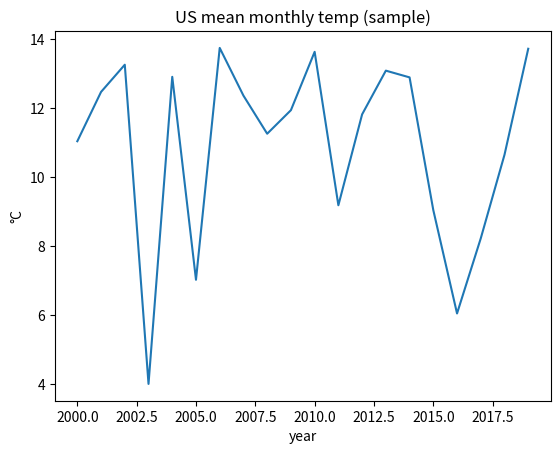

In [24]:
# Practice 1 – US stations, year ≥ 2000
raw = pd.read_csv(f'{DATA}/landtempssample.csv',
                  names=['stationid','year','month','avgtemp','latitude',
                         'longitude','elevation','station','countryid','country'],
                  skiprows=1)
lt_us = (raw.query("countryid == 'US' and year >= 2000")
            .dropna(subset=['avgtemp']))
print(lt_us.shape)
lt_us.groupby('year').avgtemp.mean().plot(title='US mean monthly temp (sample)')
plt.ylabel('°C'); plt.show()


In [25]:
# Practice 2 – GDP change 2018-2001
gdp = percapitaGDP.copy()  # from section 2 (already indexed by metro)
if 'pcGDP2018' in gdp.columns and 'pcGDP2001' in gdp.columns:
    gdp['change'] = gdp['pcGDP2018'] - gdp['pcGDP2001']
    print(gdp['change'].sort_values(ascending=False).head(8))
else:
    print('Year columns not present – check Excel import')


metro
CAN02: Montreal             36,418.00
CAN01: Toronto              16,174.00
USA03: Chicago              12,751.00
DEU01: Berlin                7,546.00
JPN01: Tokyo                -2,795.00
GBR01: London               -8,423.00
AUS03: Greater Brisbane    -11,506.00
AUS02: Greater Melbourne   -19,821.00
Name: change, dtype: float64


pass         0    1
studytime          
1         0.47 0.53
2         0.39 0.61
3         0.49 0.51
4         0.49 0.51


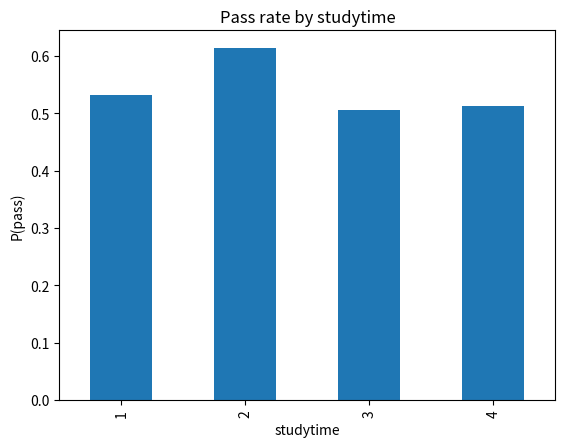

In [26]:
# Practice 3 – pass flag vs studytime
sm = pd.read_csv(f'{DATA}/studentmath.csv')
sm['pass'] = (sm['g3'] >= 10).astype(int)
print(pd.crosstab(sm['studytime'], sm['pass'], normalize='index').round(2))
sm.groupby('studytime')['pass'].mean().plot(kind='bar',
    title='Pass rate by studytime'); plt.ylabel('P(pass)'); plt.show()


---
## 8. Simulation – Parameterised Cleaning Pipeline


=== BEFORE cleaning ===
Shape: (4000, 5)
Missing avgtemp: 461

=== AFTER dropna ===
Shape: (3539, 6)
Extremes (q=0.002): 16 rows
Temp range kept: -34.8 … 56.4


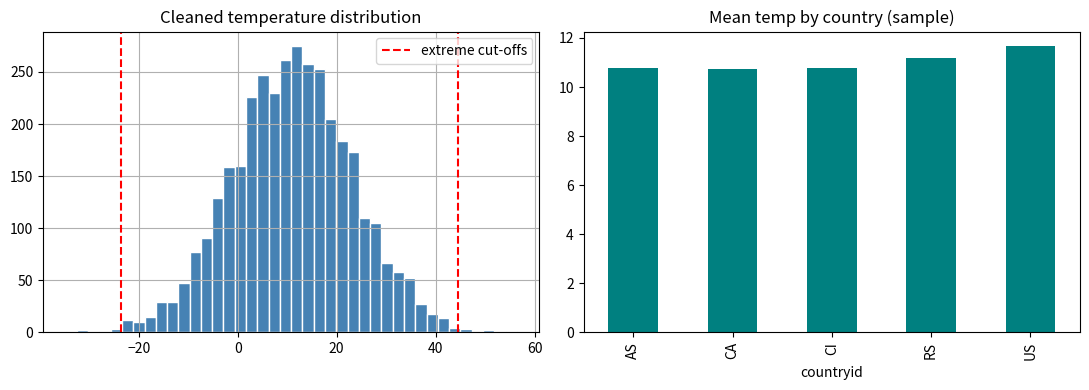

In [27]:
# ---- SIMULATION PARAMETERS (edit & re-run) ----
N_ROWS       = 4000
MISSING_RATE = 0.12
EXTREME_Q    = 0.002
RANDOM_SEED  = 123

np.random.seed(RANDOM_SEED)
sim = pd.DataFrame({
    'stationid': [f'S{i:05d}' for i in range(N_ROWS)],
    'year': np.random.randint(1950, 2021, N_ROWS),
    'month': np.random.randint(1, 13, N_ROWS),
    'avgtemp': np.random.normal(11, 12, N_ROWS),
    'countryid': np.random.choice(['US','CI','AS','RS','CA'], N_ROWS)
})
# inject missing
mask = np.random.rand(N_ROWS) < MISSING_RATE
sim.loc[mask, 'avgtemp'] = np.nan

print('=== BEFORE cleaning ===')
print('Shape:', sim.shape)
print('Missing avgtemp:', sim.avgtemp.isna().sum())

# cleaning pipeline (same steps as section 1)
sim['measuredate'] = pd.to_datetime(dict(year=sim.year, month=sim.month, day=1))
sim_clean = sim.dropna(subset=['avgtemp']).copy()
print('\n=== AFTER dropna ===')
print('Shape:', sim_clean.shape)

q_lo, q_hi = sim_clean.avgtemp.quantile([EXTREME_Q, 1-EXTREME_Q])
extremes = sim_clean[(sim_clean.avgtemp < q_lo) | (sim_clean.avgtemp > q_hi)]
print(f'Extremes (q={EXTREME_Q}): {len(extremes)} rows')
print(f'Temp range kept: {sim_clean.avgtemp.min():.1f} … {sim_clean.avgtemp.max():.1f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sim_clean.avgtemp.hist(bins=40, ax=ax[0], color='steelblue', edgecolor='white')
ax[0].set_title('Cleaned temperature distribution')
ax[0].axvline(q_lo, color='red', ls='--', label='extreme cut-offs')
ax[0].axvline(q_hi, color='red', ls='--')
ax[0].legend()
sim_clean.groupby('countryid').avgtemp.mean().plot(kind='bar', ax=ax[1], color='teal')
ax[1].set_title('Mean temp by country (sample)')
plt.tight_layout(); plt.show()


---
## Key Takeaways (quick reference)

| Source | Typical issues | First cleaning actions |
|--------|----------------|------------------------|
| CSV | all-text, bad header, multi-col dates | `names`, `parse_dates`, `dropna` |
| Excel | extra header/footer, “..” missings, spaces | `skiprows/skipfooter`, `to_numeric(errors='coerce')`, `str.strip` |
| SQL | cryptic names, coded values, 0/-1 missings | aliases in SELECT, `replace` + `category` |
| SPSS/Stata/SAS | lost value labels, many missing codes | `pyreadstat` + `set_value_labels` or manual dict |
| R (.rds) | no factors/labels | external dict + `replace` + `astype('category')` |
| Persist | lose index / dtypes | pickle (full fidelity) or feather (R interop) |

Persist only at milestones. Always inspect `dtypes`, missing counts and a few value frequencies right after import.
